# Notebook 1: Data Preprocessing & Customer Feature Engineering

**Project Title**: Intelligent Customer Behavior Analysis and Dynamic Marketing Strategy  
**Objective**: This notebook focuses on cleaning transaction-level data, mapping items to categories, engineering customer-level RFM features, splitting customers into Train/Validation/Test sets, and generating baseline distributions.

### Why Data Preprocessing is Critical:
Raw transactional datasets often contain anomalies like cancelled invoices, missing Customer IDs, and negative quantities. To construct a reliable predictive model, we must clean these anomalies and aggregate transactions into customer-level representations.

### What We Will Accomplish:
1. Load the raw transactional dataset.
2. Clean anomalies: remove missing `CustomerID`, cancelled orders, non-positive quantities and prices.
3. Engineer RFM (Recency, Frequency, Monetary) metrics, product diversity, average spend, and category spend percentage features.
4. Segment customers using a 80-10-10 split based strictly on Customer IDs (reusable across all subsequent notebooks).
5. Label customers as 'High Value' (top 20% by training Monetary value).
6. Save clean datasets and plot diagnostic charts.

### Step 1: Import Libraries and Configure Environment
We import pandas, numpy, and our custom preprocessing/plotting modules from the `src` directory.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src directory to system path for importing local packages
sys.path.append(os.path.abspath('../'))
from src.preprocessing import load_and_clean_data, get_category_map, compute_customer_rfm, split_customers
from src.utils import plot_missing_values, plot_country_distribution, plot_rfm_distributions, plot_correlation_heatmap

# Configure plotting aesthetics
%matplotlib inline
print("Libraries successfully imported!")

Libraries successfully imported!


### Step 2: Load and Clean Dataset
We load `online_retail_II.csv` and filter out missing values, cancellations (starts with 'C'), negative quantities, and prices.

In [2]:
dataset_path = '../online_retail_II.csv'
print(f"Cleaning transactional dataset from {dataset_path}...")
df_clean = load_and_clean_data(dataset_path)
print(f"Cleaned dataset size: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns.")
df_clean.head()

Cleaning transactional dataset from ../online_retail_II.csv...


Cleaned dataset size: 793309 rows, 9 columns.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


### Step 3: Map Product Categories and Aggregate to Customer RFM Profiles
Using the category mapping defined in `category_map.json`, we label descriptions and aggregate features to the customer level. We also compute category spend percentages.

In [3]:
category_map = get_category_map('../category_map.json')
print("Category Mapping definition:")
for cat, keywords in category_map.items():
    print(f"  - {cat}: {', '.join(keywords[:5])}...")
    
print("\nAggregating transactions to customer-level profiles...")
rfm_df = compute_customer_rfm(df_clean, category_map)
print(f"Generated profiles for {rfm_df.shape[0]} unique customers.")
rfm_df.head()

Category Mapping definition:
  - Homeware: HOME, MUG, CANDLE, LANTERN, CUSHION...
  - Stationery: CARD, NOTEBOOK, PEN, PAPER, ENVELOPE...
  - Gadgets: LIGHT, CLOCK, BATTERY, ALARM...
  - Decorations: CHRISTMAS, DECORATION, BUNTING, GARLAND...
  - Kitchenware: BAKING, CAKE, TIN, JAR, BOWL...
  - Else: Other...

Aggregating transactions to customer-level profiles...


Generated profiles for 5860 unique customers.


,CustomerID,Frequency,Monetary,Product_Diversity,Recency,Average_Spend_Per_Transaction,Homeware_Spend_Pct,Stationery_Spend_Pct,Gadgets_Spend_Pct,Decorations_Spend_Pct,Kitchenware_Spend_Pct,Else_Spend_Pct
0,12346,12,77556.46,27,321,6463.038333,0.000386,0.000000,0.000000,0.000193,0.995289,0.004132
1,12347,7,5408.50,123,35,772.642857,0.020190,0.117925,0.177254,0.003572,0.114265,0.566793
2,12348,5,2019.40,25,71,403.880000,0.000000,0.230861,0.000000,0.046648,0.166386,0.556106
3,12349,4,4428.69,138,14,1107.172500,0.066810,0.017206,0.010680,0.005690,0.151119,0.748494
4,12350,1,334.40,17,305,334.400000,0.000000,0.000000,0.000000,0.000000,0.118421,0.881579


### Step 4: Split Customers strictly at Customer Level
We split customers using a fixed random state `42` to ensure reproducibility: 80% Train, 10% Validation, 10% Test.

In [4]:
train_cust, val_cust, test_cust = split_customers(rfm_df['CustomerID'], random_state=42)
print(f"Dataset Splitting Results (Seed 42):")
print(f"  - Train Customers: {len(train_cust)} ({len(train_cust)/len(rfm_df)*100:.1f}%)")
print(f"  - Val Customers: {len(val_cust)} ({len(val_cust)/len(rfm_df)*100:.1f}%)")
print(f"  - Test Customers: {len(test_cust)} ({len(test_cust)/len(rfm_df)*100:.1f}%)")

# Add split indicator column to rfm_df
rfm_df['Split'] = 'Train'
rfm_df.loc[rfm_df['CustomerID'].isin(val_cust), 'Split'] = 'Val'
rfm_df.loc[rfm_df['CustomerID'].isin(test_cust), 'Split'] = 'Test'

Dataset Splitting Results (Seed 42):
  - Train Customers: 4688 (80.0%)
  - Val Customers: 586 (10.0%)
  - Test Customers: 586 (10.0%)


### Step 5: High Value Label Definition
The threshold for labeling customers as "High Value" (1) vs "Low Value" (0) is defined as the 80th percentile of **training set Monetary values** only. This static threshold is then applied to validation and test sets.

In [5]:
train_monetary = rfm_df[rfm_df['Split'] == 'Train']['Monetary']
monetary_threshold = train_monetary.quantile(0.80)
print(f"80th Percentile of Training Monetary Spend: ${monetary_threshold:.2f}")

rfm_df['High_Value'] = (rfm_df['Monetary'] >= monetary_threshold).astype(int)
print("High Value breakdown:")
print(rfm_df.groupby('Split')['High_Value'].value_counts(normalize=True).unstack())

80th Percentile of Training Monetary Spend: $2955.24
High Value breakdown:
High_Value         0         1
Split                         
Test        0.786689  0.213311
Train       0.799915  0.200085
Val         0.827645  0.172355


### Step 6: Visualizations and Diagnostics
We plot and save the required diagnostic figures: missing values, country distributions, transaction volumes, RFM distributions, and the correlation heatmap.

Generating and saving diagnostic plots...


D:\musa wisal\6th sem\ML\final\src\utils.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_counts, x='Count', y='Country', ax=ax, palette='viridis')


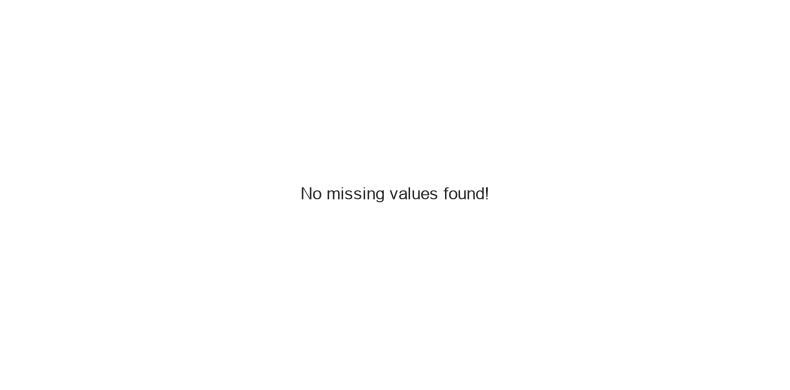

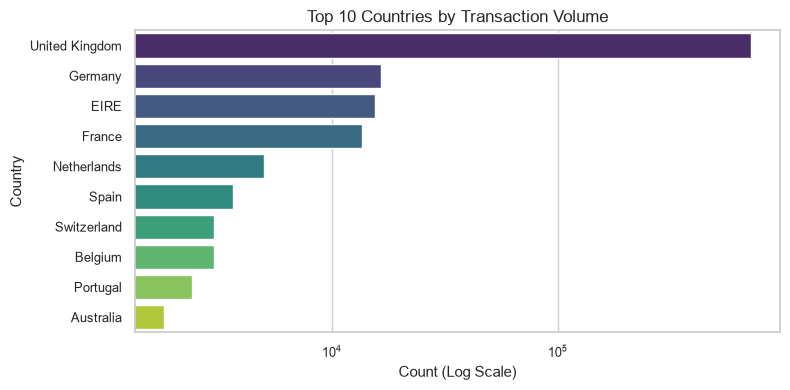

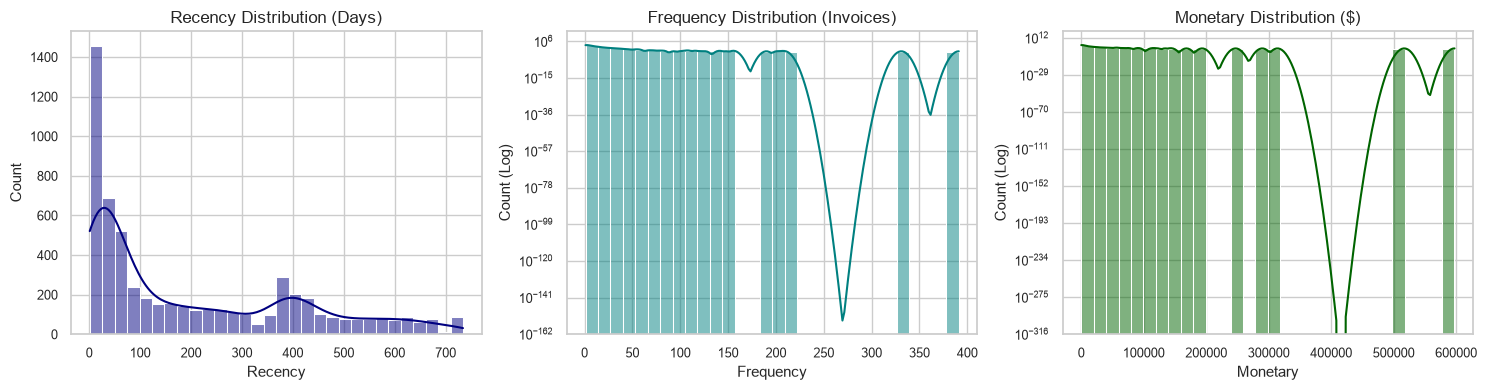

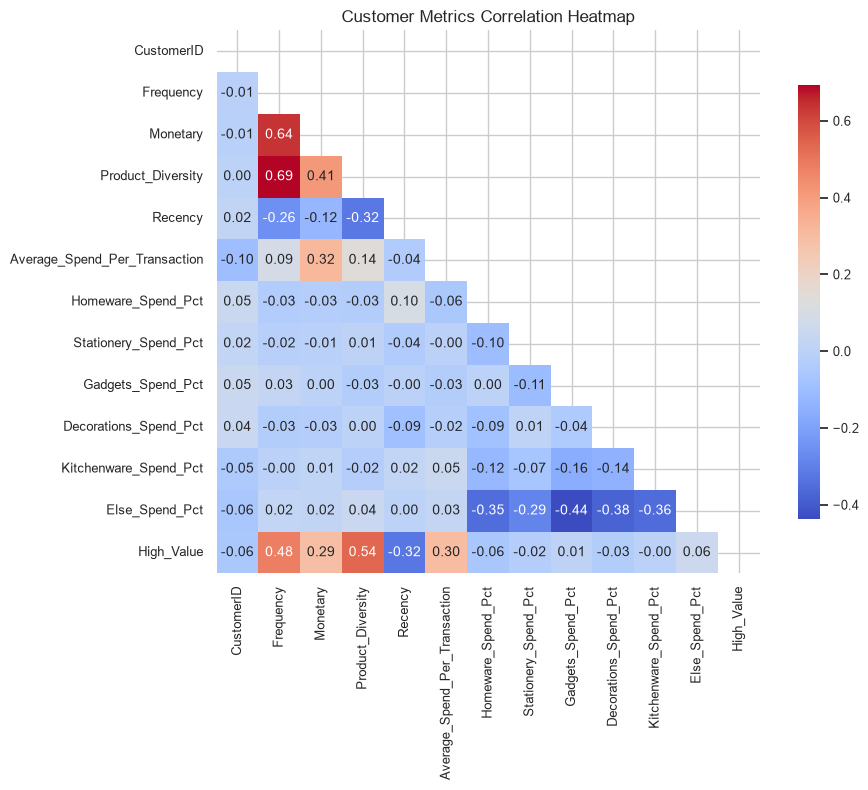

In [6]:
os.makedirs('../data/plots', exist_ok=True)

print("Generating and saving diagnostic plots...")
fig_miss = plot_missing_values(df_clean, save_path='../data/plots/missing_values.png')
fig_cnt = plot_country_distribution(df_clean, save_path='../data/plots/country_distribution.png')
fig_rfm = plot_rfm_distributions(rfm_df, save_path='../data/plots/rfm_distributions.png')
fig_corr = plot_correlation_heatmap(rfm_df, title='Customer Metrics Correlation Heatmap', save_path='../data/plots/correlation_heatmap.png')
plt.show()

### Step 7: Save Processed Outputs
We save the processed customer profile DataFrame, splits, and labels for downstream modeling notebooks.

In [7]:
processed_path = '../data/processed_customers.csv'
rfm_df.to_csv(processed_path, index=False)
print(f"Saved processed customer profiles to {processed_path} successfully!")

Saved processed customer profiles to ../data/processed_customers.csv successfully!
